## Setup

In [1]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
import contextily as ctx
import xyzservices as xyz
import matplotlib.pyplot as plt

# import kml reading and set supported driver
import fiona
fiona.drvsupport.supported_drivers["KML"] = "rw"

In [3]:
from gridsample.utils import create_ids, save_shapefiles

In [4]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data_india"
RAW_DATA_DIR = DATA_DIR / "00_raw"
PROCESSED_DATA_DIR = DATA_DIR / "01_processed" / "golden_city"

## Load region shapes

In [5]:
colony_gdf = gpd.read_file(
    RAW_DATA_DIR / "colony_shapes" / "colony_shapes.kml",
    crs="4326",
    driver="KML",
).drop(columns=["Description"])

In [6]:
# remove z-dimension from shapes
colony_gdf.geometry = colony_gdf.geometry.apply(lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2)))

In [7]:
colony_gdf

,Name,geometry
0,Golden City,"POLYGON ((77.47053 23.16622, 77.47127 23.16764..."


## Rooftops

In [8]:
from s2cell.s2cell import lat_lon_to_cell_id
import boto3

### Download rooftop data

Get the ID of the level 6 S2 Cell that this colony sits inside

In [9]:
s2_cell_id = lat_lon_to_cell_id(lat=colony_gdf.centroid.y, lon=colony_gdf.centroid.x, level=6)
s2_cell_id

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_64013/3190238580.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_cell_id = lat_lon_to_cell_id(lat=colony_gdf.centroid.y, lon=colony_gdf.centroid.x, level=6)
/Users/amiremami/miniconda3/envs/gridsample/lib/python3.11/site-packages/s2cell/s2cell.py:649: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lat_rad = math.radians(lat)
/Users/amiremami/miniconda3/envs/gridsample/lib/python3.11/site-packages/s2cell/s2cell.py:650: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lon_rad = math.radians(lon)


4142467232250724352


Download closest S2 cell shapefile from https://beta.source.coop/vida/google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/

In [10]:
s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"

if s2_rooftops_path.exists():
    print("File already exists")
else:
    s3 = boto3.client("s3", endpoint_url="https://data.source.coop")
    s3.download_file(
        "vida",
        f"google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/{s2_cell_id}.parquet",
        str(s2_rooftops_path),
    )
    print("File downloaded.")

File already exists


### Load and process rooftop data

<Axes: >

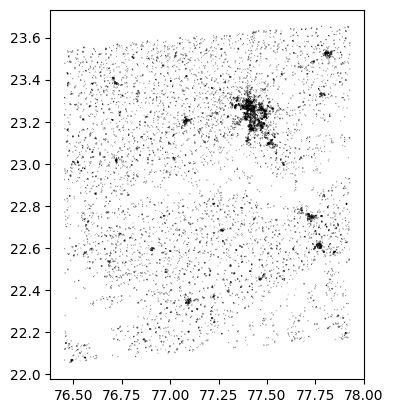

In [11]:
rooftop_gdf = gpd.read_parquet(s2_rooftops_path)
rooftop_gdf.sample(10000).plot(edgecolor="k")

In [12]:
rooftop_gdf = rooftop_gdf.drop(columns=["boundary_id", "s2_id", "geohash", "bbox", "country_iso"])

In [13]:
rooftop_gdf["rooftop_id"] = create_ids(len(rooftop_gdf), f"ROOFTOP_S2_{s2_cell_id}_")

In [14]:
rooftop_gdf

,bf_source,confidence,area_in_meters,geometry,rooftop_id
1312452,google,0.7285,23.7821,"POLYGON ((76.46367 22.05372, 76.46362 22.05372...",ROOFTOP_S2_4142467232250724352_0000001
1515388,google,0.7153,9.8125,"POLYGON ((76.46483 22.05428, 76.46483 22.05432...",ROOFTOP_S2_4142467232250724352_0000002
1710778,google,0.7004,7.0812,"POLYGON ((76.45724 22.05924, 76.45724 22.05927...",ROOFTOP_S2_4142467232250724352_0000003
1252889,microsoft,NaN,68.3447,"POLYGON ((76.45754 22.06020, 76.45746 22.06020...",ROOFTOP_S2_4142467232250724352_0000004
1251238,microsoft,NaN,40.9520,"POLYGON ((76.46078 22.05540, 76.46086 22.05541...",ROOFTOP_S2_4142467232250724352_0000005
...,...,...,...,...,...
566629,microsoft,NaN,25.4265,"POLYGON ((77.91525 23.66157, 77.91520 23.66158...",ROOFTOP_S2_4142467232250724352_2793461
567977,google,0.7441,29.2368,"POLYGON ((77.91905 23.66114, 77.91899 23.66116...",ROOFTOP_S2_4142467232250724352_2793462
567059,google,0.8234,159.8137,"POLYGON ((77.91913 23.66124, 77.91902 23.66128...",ROOFTOP_S2_4142467232250724352_2793463
566685,microsoft,NaN,25.7559,"POLYGON ((77.91606 23.66377, 77.91600 23.66377...",ROOFTOP_S2_4142467232250724352_2793464


### Match rooftops to colony

In [15]:
subset_rooftops_gdf = rooftop_gdf.sjoin(colony_gdf, how="inner", predicate="intersects").drop(columns=["index_right"])
subset_rooftops_gdf

,bf_source,confidence,area_in_meters,geometry,rooftop_id,Name
912838,google,0.6631,15.7373,"POLYGON ((77.47003 23.16701, 77.47001 23.16705...",ROOFTOP_S2_4142467232250724352_2015056,Golden City
686439,google,0.6634,10.3174,"POLYGON ((77.47002 23.16701, 77.47000 23.16700...",ROOFTOP_S2_4142467232250724352_2015057,Golden City
1185505,google,0.6713,15.7811,"POLYGON ((77.46996 23.16721, 77.46993 23.16725...",ROOFTOP_S2_4142467232250724352_2015059,Golden City
1022640,google,0.7871,104.3085,"POLYGON ((77.47011 23.16713, 77.47007 23.16720...",ROOFTOP_S2_4142467232250724352_2015060,Golden City
950556,google,0.8437,42.1019,"POLYGON ((77.47002 23.16721, 77.46999 23.16727...",ROOFTOP_S2_4142467232250724352_2015061,Golden City
...,...,...,...,...,...,...
1021990,google,0.6621,13.4010,"POLYGON ((77.47084 23.17075, 77.47085 23.17081...",ROOFTOP_S2_4142467232250724352_2018238,Golden City
602205,google,0.8630,143.4748,"POLYGON ((77.47023 23.17109, 77.47015 23.17109...",ROOFTOP_S2_4142467232250724352_2018239,Golden City
946463,google,0.8497,146.7107,"POLYGON ((77.47035 23.17107, 77.47028 23.17107...",ROOFTOP_S2_4142467232250724352_2018240,Golden City
803799,google,0.8302,146.6340,"POLYGON ((77.47031 23.17090, 77.47016 23.17090...",ROOFTOP_S2_4142467232250724352_2018241,Golden City


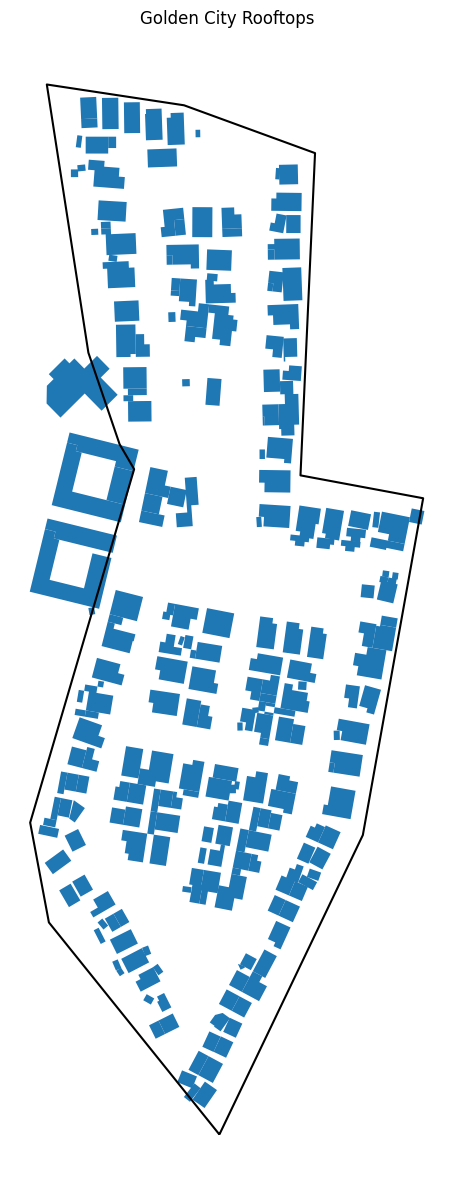

In [16]:
ax = subset_rooftops_gdf.plot(figsize=(10,15))
# ctx.add_basemap(ax, crs=subset_rooftops_gdf.crs.to_string(), source=xyz.TileProvider.from_qms("Google Satellite Hybrid"))
ax.set_axis_off()
plt.title("Golden City Rooftops")
colony_gdf.boundary.plot(ax=ax, color="k")
plt.savefig(PROCESSED_DATA_DIR / "subset_rooftops.png", bbox_inches="tight")

In [17]:
save_shapefiles(
    subset_rooftops_gdf,
    PROCESSED_DATA_DIR,
    "golden_city_rooftops",
    formats=["parquet"],
)

In [18]:
save_shapefiles(
    subset_rooftops_gdf[["Name", "geometry"]],
    PROCESSED_DATA_DIR,
    "golden_city_rooftops",
    formats=["geojson"],
)

## Get rooftop stats

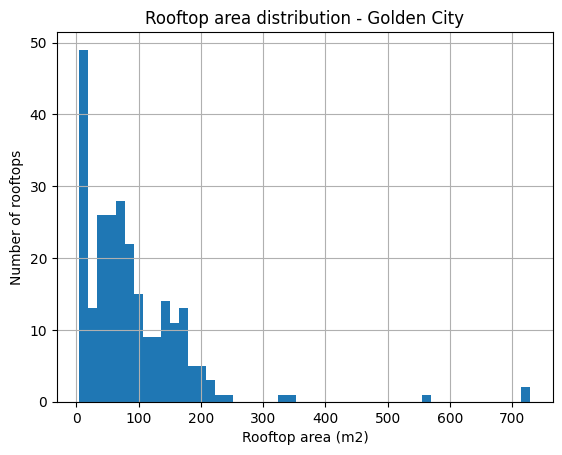

In [19]:
subset_rooftops_gdf["area_in_meters"].hist(bins=50)
plt.xlabel("Rooftop area (m2)")
plt.ylabel("Number of rooftops")
plt.title("Rooftop area distribution - Golden City")
plt.savefig(PROCESSED_DATA_DIR / "rooftop_area_distribution.png")

In [20]:
subset_rooftops_gdf["rooftop_area_category"] = pd.cut(
    subset_rooftops_gdf["area_in_meters"],
    bins=[
        0,
        20,
        50,
        100,
        200,
        300,
        400,
        500,
        np.inf,
    ],
    labels=[
        "Rooftop count <20m2",
        "Rooftop count 20-50m2",
        "Rooftop count 50-100m2",
        "Rooftop count 100-200m2",
        "Rooftop count 200-300m2",
        "Rooftop count 300-400m2",
        "Rooftop count 400-500m2",
        "Rooftop count >500m2",
    ],
)

In [21]:
pivot_df = subset_rooftops_gdf.pivot_table(index='Name', columns='rooftop_area_category', aggfunc='size', fill_value=0)
pivot_df = pivot_df.reset_index()

pivot_df.insert(1, "total_rooftops", len(subset_rooftops_gdf))
pivot_df.insert(2, "total_rooftop_area", subset_rooftops_gdf['area_in_meters'].sum())


pivot_df

rooftop_area_category,Name,total_rooftops,total_rooftop_area,Rooftop count <20m2,Rooftop count 20-50m2,Rooftop count 50-100m2,Rooftop count 100-200m2,Rooftop count 200-300m2,Rooftop count 300-400m2,Rooftop count 400-500m2,Rooftop count >500m2
0,Golden City,255,22767.9997,49,43,78,75,5,2,0,3


In [22]:
pivot_df.to_csv(PROCESSED_DATA_DIR / "golden_city_rooftop_stats.csv", index=False)

## PV Potential

In [24]:
import rasterio
from rasterio.plot import show
from rasterstats import zonal_stats

In [25]:
# load the raster
raster_path = (
    RAW_DATA_DIR
    / "solar_atlas"
    / "India_GISdata_LTAy_YearlyMonthlyTotals_GlobalSolarAtlas-v2_GEOTIFF"
    / "GTI.tif"
)

In [26]:
raster = rasterio.open(raster_path)
raster

<open DatasetReader name='../data_india/00_raw/solar_atlas/India_GISdata_LTAy_YearlyMonthlyTotals_GlobalSolarAtlas-v2_GEOTIFF/GTI.tif' mode='r'>

In [27]:
raster.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': 1.1754943508222875e-38,
 'width': 12800,
 'height': 12800,
 'count': 1,
 'crs': CRS.from_epsg(4326),
 'transform': Affine(0.0025, 0.0, 66.0,
        0.0, -0.0025, 38.0)}

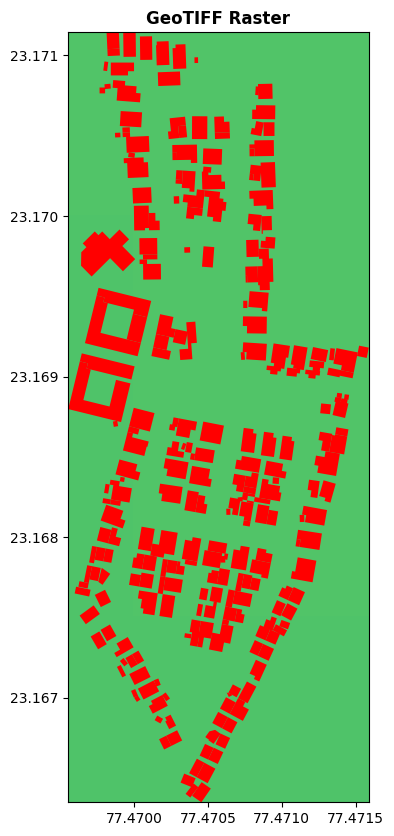

In [31]:
fig, ax = plt.subplots(figsize=(10, 10))

show(raster, ax=ax, title="GeoTIFF Raster")
subset_rooftops_gdf.plot(ax=ax, color="r")

# restrict the extent of the plot to the extent of the shapes
ax.set_xlim(subset_rooftops_gdf.total_bounds[[0, 2]])
ax.set_ylim(subset_rooftops_gdf.total_bounds[[1, 3]])
plt.show()

In [32]:
# Read the raster values
array = raster.read(1)
# Get the affine
affine = raster.transform

In [35]:
zonal_stats(subset_rooftops_gdf, array, affine=affine, nodata=raster.nodata, stats=['sum'])

[{'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum': None},
 {'sum':